# Data Exploration (Unified Dataset)

Here we check the distribution of saliency maps across ALL 3 datasets (SALICON, ECdata, UEyes) to see if we have a Center Bias (whether most people look at the center of the screen).

In [ ]:
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import sys
import os
sys.path.append('..')

from dataset import load_all_datasets, UnifiedDataset

In [2]:
# load unified data (using our custom loader)
df_train = load_all_datasets('train')
train_dataset = UnifiedDataset(df_train)

print(f"We have {len(train_dataset)} training images across all datasets.")

We have 12743 training images across all datasets.


  0%|          | 0/12743 [00:00<?, ?it/s]

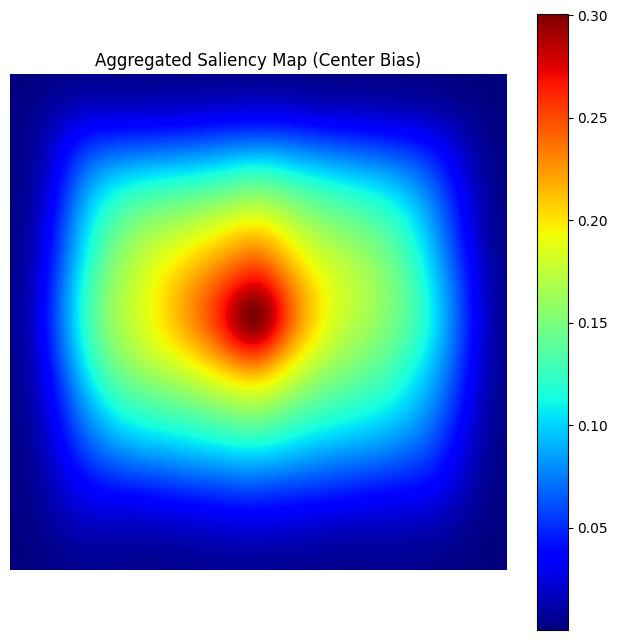

In [3]:
# Check Center Bias on images
num_samples = len(train_dataset)
sum_map = torch.zeros(1, 224, 224)

for i in tqdm(range(num_samples)):
    img, smap = train_dataset[i]
    sum_map += smap

# divide by number of samples to get the average
avg_map = sum_map / num_samples

# Plot the result
plt.figure(figsize=(8, 8))
plt.title("Aggregated Saliency Map (Center Bias)")
plt.imshow(avg_map.squeeze().numpy(), cmap='jet')
plt.colorbar()
plt.axis('off')
plt.show()

### Conclusion: Center Bias

![Center Bias](center_bias.png)

As we can see, there is a strong **Center Bias** in our dataset. This is not a mistake! The human eye naturally tends to look at the center of an image, and photographers usually place the main subject there. 

For now, we will leave the data as it is so the model learns this natural behavior. However, later during evaluation, we might need to penalize the model (e.g., using sAUC metrics) to ensure it doesn't just "cheat" by always predicting the center.